# Customer Segmentation Using Machine Learning

### Objective
Segment customers based on demographic characteristics and purchasing behavior using machine learning, analyze customer preferences, visualize meaningful customer segments, and generate targeted business insights.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA

In [2]:
from google.colab import files

uploaded = files.upload()

Saving marketing_campaign.csv to marketing_campaign.csv


In [3]:
df = pd.read_csv("marketing_campaign.csv", sep="\t")

In [4]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [5]:
df.shape

(2240, 29)

In [6]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [8]:
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,2240.0,5592.159821,3246.662198,0.0,2828.25,5458.5,8427.75,11191.0
Year_Birth,2240.0,1968.805804,11.984069,1893.0,1959.00,1970.0,1977.00,1996.0
Income,2216.0,52247.251354,25173.076661,1730.0,35303.00,51381.5,68522.00,666666.0
Kidhome,2240.0,0.444196,0.538398,0.0,0.00,0.0,1.00,2.0
Teenhome,2240.0,0.506250,0.544538,0.0,0.00,0.0,1.00,2.0
Recency,2240.0,49.109375,28.962453,0.0,24.00,49.0,74.00,99.0
MntWines,2240.0,303.935714,336.597393,0.0,23.75,173.5,504.25,1493.0
MntFruits,2240.0,26.302232,39.773434,0.0,1.00,8.0,33.00,199.0
MntMeatProducts,2240.0,166.950000,225.715373,0.0,16.00,67.0,232.00,1725.0
MntFishProducts,2240.0,37.525446,54.628979,0.0,3.00,12.0,50.00,259.0


In [11]:
df['Year_Birth'].value_counts().sort_index().head(20)

,count
Year_Birth,
1893,1
1899,1
1900,1
1940,1
1941,1
1943,7
1944,7
1945,8
1946,16


In [12]:
df['Income'].sort_values(ascending=False).head(20)

,Income
2233,666666.0
617,162397.0
687,160803.0
1300,157733.0
164,157243.0
1653,157146.0
2132,156924.0
655,153924.0
1898,113734.0
646,105471.0


In [13]:
df[df['Income'].isnull()]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
10,1994,1983,Graduation,Married,NaN,1,0,15-11-2013,11,5,...,7,0,0,0,0,0,0,3,11,0
27,5255,1986,Graduation,Single,NaN,1,0,20-02-2013,19,5,...,1,0,0,0,0,0,0,3,11,0
43,7281,1959,PhD,Single,NaN,0,0,05-11-2013,80,81,...,2,0,0,0,0,0,0,3,11,0
48,7244,1951,Graduation,Single,NaN,2,1,01-01-2014,96,48,...,6,0,0,0,0,0,0,3,11,0
58,8557,1982,Graduation,Single,NaN,1,0,17-06-2013,57,11,...,6,0,0,0,0,0,0,3,11,0
71,10629,1973,2n Cycle,Married,NaN,1,0,14-09-2012,25,25,...,8,0,0,0,0,0,0,3,11,0
90,8996,1957,PhD,Married,NaN,2,1,19-11-2012,4,230,...,9,0,0,0,0,0,0,3,11,0
91,9235,1957,Graduation,Single,NaN,1,1,27-05-2014,45,7,...,7,0,0,0,0,0,0,3,11,0
92,5798,1973,Master,Together,NaN,0,0,23-11-2013,87,445,...,1,0,0,0,0,0,0,3,11,0
128,8268,1961,PhD,Married,NaN,0,1,11-07-2013,23,352,...,6,0,0,0,0,0,0,3,11,0


In [14]:
df_clean = df.copy()

In [15]:
df_clean = df_clean.drop(columns=['Z_CostContact', 'Z_Revenue'])

In [16]:
df_clean.loc[df_clean['Income'] == 666666, 'Income'] = np.nan

In [17]:
income_median = df_clean['Income'].median()

df_clean['Income'] = df_clean['Income'].fillna(income_median)

In [18]:
df_clean['Income'].isnull().sum()

np.int64(0)

In [19]:
df_clean['Age'] = 2014 - df_clean['Year_Birth']

In [20]:
df_clean['Age'].describe()

,Age
count,2240.000000
mean,45.194196
std,11.984069
min,18.000000
25%,37.000000
50%,44.000000
75%,55.000000
max,121.000000


In [21]:
df_clean[df_clean['Age'] > 100][['ID', 'Year_Birth', 'Age', 'Income']]

,ID,Year_Birth,Age,Income
192,7829,1900,114,36640.0
239,11004,1893,121,60182.0
339,1150,1899,115,83532.0


In [22]:
df_clean = df_clean[df_clean['Age'] <= 100].copy()

In [23]:
df_clean.shape

(2237, 28)

In [24]:
df_clean['Age'].describe()

,Age
count,2237.000000
mean,45.098346
std,11.701917
min,18.000000
25%,37.000000
50%,44.000000
75%,55.000000
max,74.000000


In [25]:
print(df_clean['Education'].value_counts())
print(df_clean['Marital_Status'].value_counts())

Education
Graduation    1127
PhD            485
Master         370
2n Cycle       201
Basic           54
Name: count, dtype: int64
Marital_Status
Married     864
Together    579
Single      479
Divorced    231
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64


In [26]:
df_clean['Marital_Status'] = df_clean['Marital_Status'].replace(
    ['Alone', 'Absurd', 'YOLO'], 'Other'
)

In [27]:
df_clean['Marital_Status'].value_counts()

,count
Marital_Status,
Married,864
Together,579
Single,479
Divorced,231
Widow,77
Other,7


In [28]:
df_clean['Dt_Customer'] = pd.to_datetime(
    df_clean['Dt_Customer'],
    dayfirst=True
)

In [29]:
df_clean['Customer_Tenure_Days'] = (
    df_clean['Dt_Customer'].max() - df_clean['Dt_Customer']
).dt.days

In [30]:
spending_cols = [
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds'
]

df_clean['Total_Spending'] = df_clean[spending_cols].sum(axis=1)

In [31]:
purchase_cols = [
    'NumWebPurchases',
    'NumCatalogPurchases',
    'NumStorePurchases'
]

df_clean['Total_Purchases'] = df_clean[purchase_cols].sum(axis=1)

In [32]:
df_clean['Total_Children'] = (
    df_clean['Kidhome'] + df_clean['Teenhome']
)

In [33]:
campaign_cols = [
    'AcceptedCmp1',
    'AcceptedCmp2',
    'AcceptedCmp3',
    'AcceptedCmp4',
    'AcceptedCmp5'
]

df_clean['Total_Campaign_Accepted'] = df_clean[campaign_cols].sum(axis=1)

In [34]:
df_clean['Total_Purchase_Channels'] = (
    (df_clean['NumWebPurchases'] > 0).astype(int) +
    (df_clean['NumCatalogPurchases'] > 0).astype(int) +
    (df_clean['NumStorePurchases'] > 0).astype(int)
)

In [35]:
for col in spending_cols:
    df_clean[col + '_Share'] = (
        df_clean[col] / df_clean['Total_Spending'].replace(0, np.nan)
    )

df_clean[[col + '_Share' for col in spending_cols]] = (
    df_clean[[col + '_Share' for col in spending_cols]]
    .fillna(0)
)

In [36]:
df_clean['Avg_Spending_Per_Purchase'] = (
    df_clean['Total_Spending'] /
    df_clean['Total_Purchases'].replace(0, np.nan)
).fillna(0)

In [37]:
df_clean['Web_Conversion_Ratio'] = (
    df_clean['NumWebPurchases'] /
    df_clean['NumWebVisitsMonth'].replace(0, np.nan)
).fillna(0)

In [38]:
df_clean['Household_Size'] = 1 + df_clean['Total_Children']

In [39]:
df_clean[
    [
        'Age',
        'Income',
        'Total_Spending',
        'Total_Purchases',
        'Total_Children',
        'Total_Campaign_Accepted',
        'Total_Purchase_Channels',
        'Avg_Spending_Per_Purchase',
        'Web_Conversion_Ratio',
        'Household_Size'
    ]
].head()

,Age,Income,Total_Spending,Total_Purchases,Total_Children,Total_Campaign_Accepted,Total_Purchase_Channels,Avg_Spending_Per_Purchase,Web_Conversion_Ratio,Household_Size
0,57,58138.0,1617,22,0,0,3,73.500000,1.142857,1
1,60,46344.0,27,4,2,0,3,6.750000,0.200000,3
2,49,71613.0,776,20,0,0,3,38.800000,2.000000,1
3,30,26646.0,53,6,1,0,2,8.833333,0.333333,2
4,33,58293.0,422,14,1,0,3,30.142857,1.000000,2


In [40]:
df_clean.shape

(2237, 43)

In [41]:
df_clean.columns.tolist()

['ID',
 'Year_Birth',
 'Education',
 'Marital_Status',
 'Income',
 'Kidhome',
 'Teenhome',
 'Dt_Customer',
 'Recency',
 'MntWines',
 'MntFruits',
 'MntMeatProducts',
 'MntFishProducts',
 'MntSweetProducts',
 'MntGoldProds',
 'NumDealsPurchases',
 'NumWebPurchases',
 'NumCatalogPurchases',
 'NumStorePurchases',
 'NumWebVisitsMonth',
 'AcceptedCmp3',
 'AcceptedCmp4',
 'AcceptedCmp5',
 'AcceptedCmp1',
 'AcceptedCmp2',
 'Complain',
 'Response',
 'Age',
 'Customer_Tenure_Days',
 'Total_Spending',
 'Total_Purchases',
 'Total_Children',
 'Total_Campaign_Accepted',
 'Total_Purchase_Channels',
 'MntWines_Share',
 'MntFruits_Share',
 'MntMeatProducts_Share',
 'MntFishProducts_Share',
 'MntSweetProducts_Share',
 'MntGoldProds_Share',
 'Avg_Spending_Per_Purchase',
 'Web_Conversion_Ratio',
 'Household_Size']

In [42]:
df_clean[
    [
        'Age',
        'Income',
        'Total_Spending',
        'Total_Purchases',
        'Total_Children',
        'Total_Campaign_Accepted',
        'Total_Purchase_Channels',
        'Avg_Spending_Per_Purchase',
        'Web_Conversion_Ratio',
        'Household_Size',
        'Recency'
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,2237.0,45.098346,11.701917,18.0,37.000000,44.000000,55.000,74.0
Income,2237.0,51952.263746,21406.684379,1730.0,35523.000000,51373.000000,68274.000,162397.0
Total_Spending,2237.0,605.743406,601.840466,5.0,69.000000,396.000000,1045.000,2525.0
Total_Purchases,2237.0,12.544032,7.205919,0.0,6.000000,12.000000,18.000,32.0
Total_Children,2237.0,0.950827,0.752037,0.0,0.000000,1.000000,1.000,3.0
Total_Campaign_Accepted,2237.0,0.297720,0.678615,0.0,0.000000,0.000000,0.000,4.0
Total_Purchase_Channels,2237.0,2.709879,0.507859,0.0,2.000000,3.000000,3.000,3.0
Avg_Spending_Per_Purchase,2237.0,38.086329,45.890393,0.0,13.000000,29.642857,49.125,1679.0
Web_Conversion_Ratio,2237.0,1.086077,1.328212,0.0,0.333333,0.750000,1.500,27.0
Household_Size,2237.0,1.950827,0.752037,1.0,1.000000,2.000000,2.000,4.0


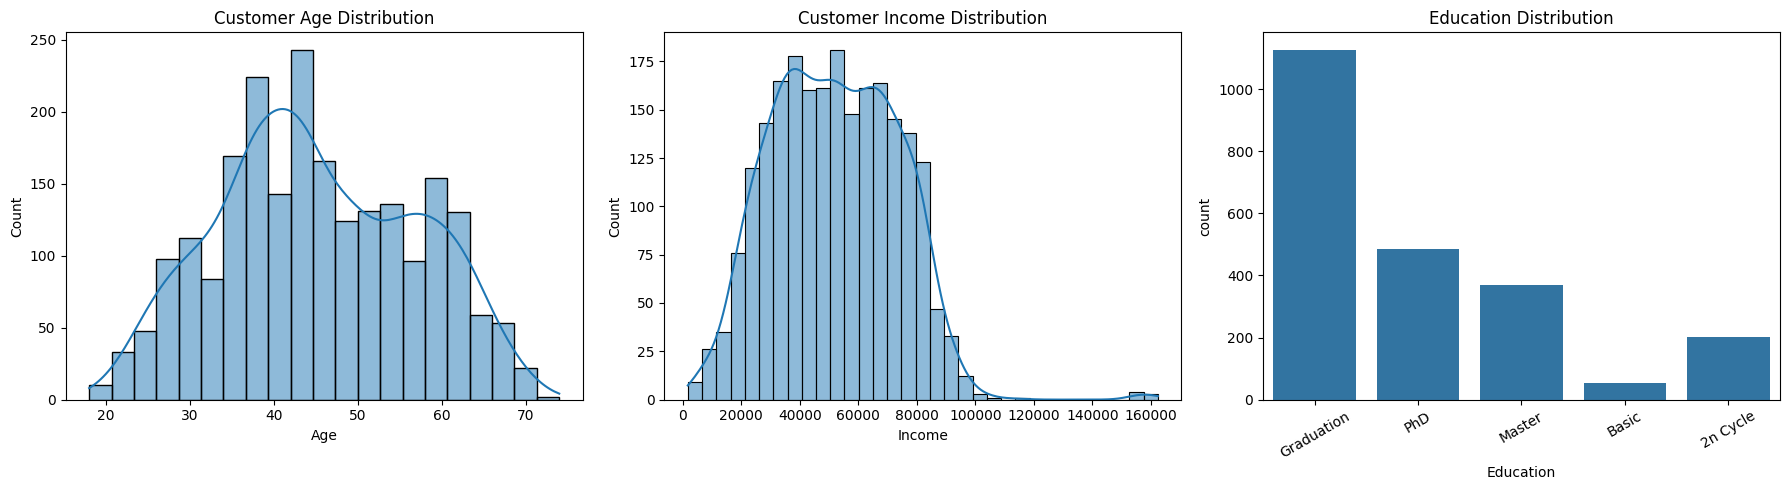

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df_clean['Age'], kde=True, ax=axes[0])
axes[0].set_title('Customer Age Distribution')

sns.histplot(df_clean['Income'], kde=True, ax=axes[1])
axes[1].set_title('Customer Income Distribution')

sns.countplot(data=df_clean, x='Education', ax=axes[2])
axes[2].set_title('Education Distribution')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

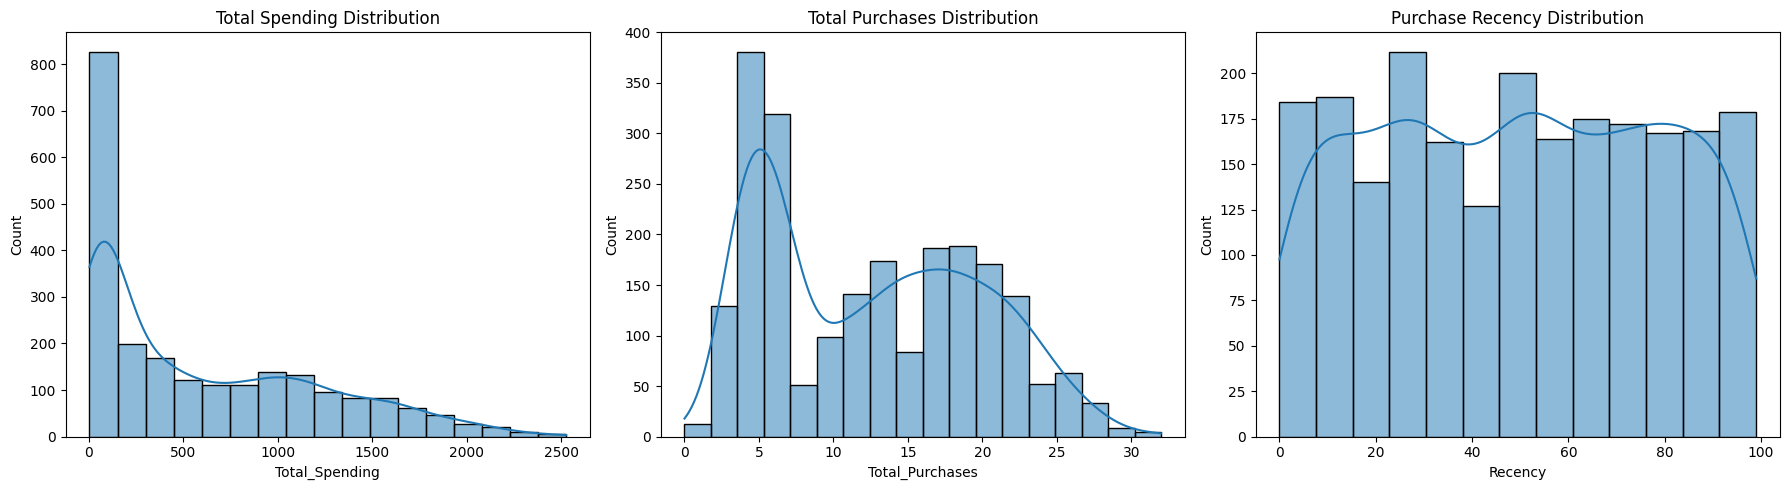

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df_clean['Total_Spending'], kde=True, ax=axes[0])
axes[0].set_title('Total Spending Distribution')

sns.histplot(df_clean['Total_Purchases'], kde=True, ax=axes[1])
axes[1].set_title('Total Purchases Distribution')

sns.histplot(df_clean['Recency'], kde=True, ax=axes[2])
axes[2].set_title('Purchase Recency Distribution')

plt.tight_layout()
plt.show()

In [45]:
product_totals = df_clean[spending_cols].sum().sort_values(ascending=False)

product_totals

,0
MntWines,680038
MntMeatProducts,373393
MntGoldProds,98358
MntFishProducts,83939
MntSweetProducts,60553
MntFruits,58767


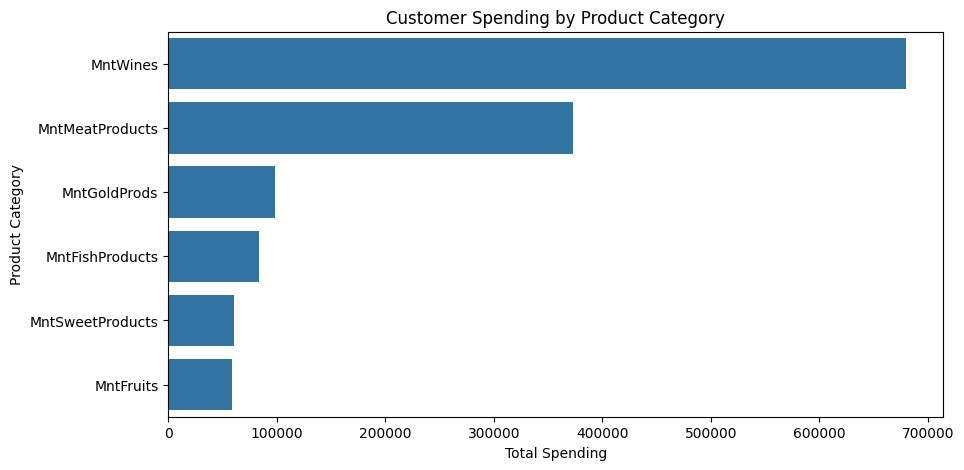

In [46]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=product_totals.values,
    y=product_totals.index
)

plt.title('Customer Spending by Product Category')
plt.xlabel('Total Spending')
plt.ylabel('Product Category')
plt.show()

In [47]:
clustering_features = [
    'Age',
    'Income',
    'Recency',
    'Total_Spending',
    'Total_Purchases',
    'Total_Children',
    'Total_Campaign_Accepted',
    'Total_Purchase_Channels',
    'Avg_Spending_Per_Purchase',
    'Web_Conversion_Ratio',
    'Household_Size'
]

In [48]:
preference_features = [
    col + '_Share' for col in spending_cols
]

clustering_features.extend(preference_features)

In [49]:
clustering_features

['Age',
 'Income',
 'Recency',
 'Total_Spending',
 'Total_Purchases',
 'Total_Children',
 'Total_Campaign_Accepted',
 'Total_Purchase_Channels',
 'Avg_Spending_Per_Purchase',
 'Web_Conversion_Ratio',
 'Household_Size',
 'MntWines_Share',
 'MntFruits_Share',
 'MntMeatProducts_Share',
 'MntFishProducts_Share',
 'MntSweetProducts_Share',
 'MntGoldProds_Share']

In [50]:
X = df_clean[clustering_features].copy()

In [51]:
X.isnull().sum().sum()

np.int64(0)

In [52]:
np.isinf(X).sum().sum()

np.int64(0)

In [53]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,2237.0,45.098346,11.701917,18.0,37.000000,44.000000,55.000000,74.000000
Income,2237.0,51952.263746,21406.684379,1730.0,35523.000000,51373.000000,68274.000000,162397.000000
Recency,2237.0,49.104604,28.956073,0.0,24.000000,49.000000,74.000000,99.000000
Total_Spending,2237.0,605.743406,601.840466,5.0,69.000000,396.000000,1045.000000,2525.000000
Total_Purchases,2237.0,12.544032,7.205919,0.0,6.000000,12.000000,18.000000,32.000000
Total_Children,2237.0,0.950827,0.752037,0.0,0.000000,1.000000,1.000000,3.000000
Total_Campaign_Accepted,2237.0,0.297720,0.678615,0.0,0.000000,0.000000,0.000000,4.000000
Total_Purchase_Channels,2237.0,2.709879,0.507859,0.0,2.000000,3.000000,3.000000,3.000000
Avg_Spending_Per_Purchase,2237.0,38.086329,45.890393,0.0,13.000000,29.642857,49.125000,1679.000000
Web_Conversion_Ratio,2237.0,1.086077,1.328212,0.0,0.333333,0.750000,1.500000,27.000000


In [54]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [55]:
X_scaled.shape

(2237, 17)

In [56]:
inertia = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

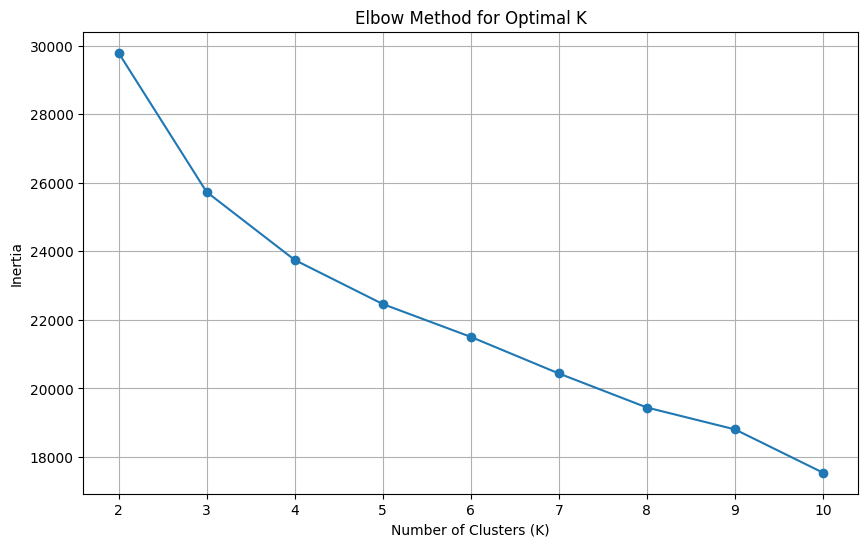

In [57]:
plt.figure(figsize=(10, 6))

plt.plot(K_range, inertia, marker='o')

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.xticks(K_range)
plt.grid(True)
plt.show()

In [58]:
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

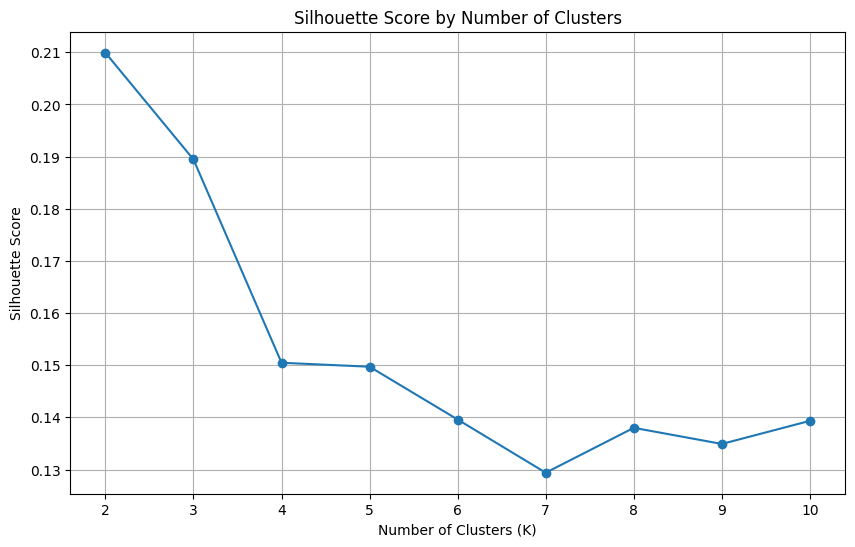

In [59]:
plt.figure(figsize=(10, 6))

plt.plot(K_range, silhouette_scores, marker='o')

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score by Number of Clusters')
plt.xticks(K_range)
plt.grid(True)
plt.show()

In [60]:
davies_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    score = davies_bouldin_score(X_scaled, labels)
    davies_scores.append(score)

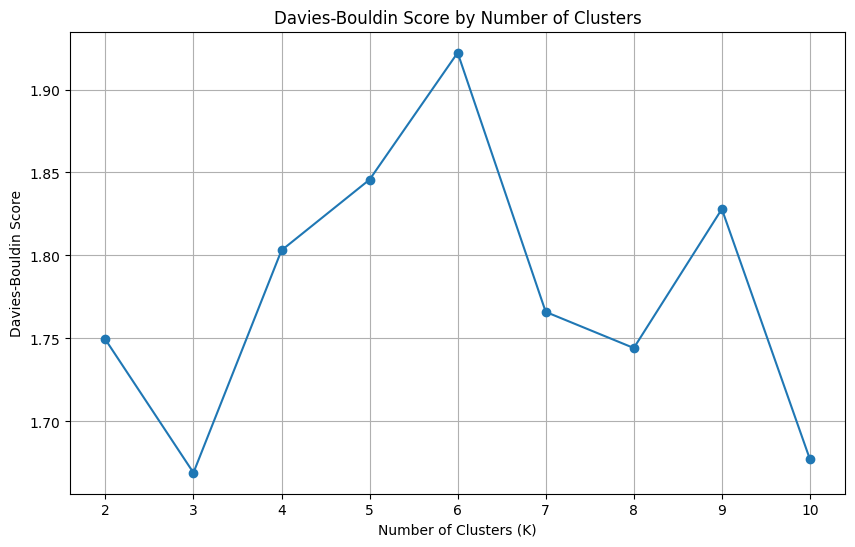

In [61]:
plt.figure(figsize=(10, 6))

plt.plot(K_range, davies_scores, marker='o')

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Davies-Bouldin Score')
plt.title('Davies-Bouldin Score by Number of Clusters')
plt.xticks(K_range)
plt.grid(True)
plt.show()

In [62]:
calinski_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    score = calinski_harabasz_score(X_scaled, labels)
    calinski_scores.append(score)

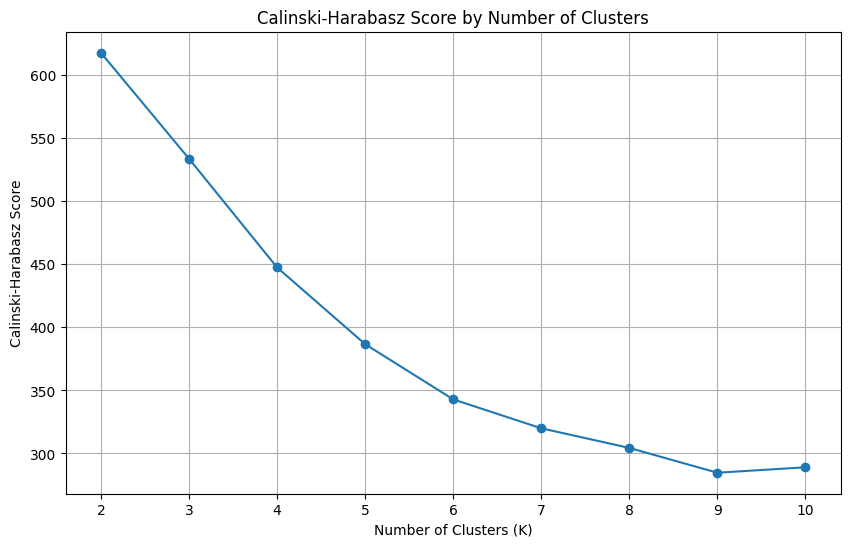

In [63]:
plt.figure(figsize=(10, 6))

plt.plot(K_range, calinski_scores, marker='o')

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Calinski-Harabasz Score')
plt.title('Calinski-Harabasz Score by Number of Clusters')
plt.xticks(K_range)
plt.grid(True)
plt.show()

In [64]:
optimal_k = 3

kmeans_final = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=20
)

cluster_labels = kmeans_final.fit_predict(X_scaled)

In [65]:
df_clean['Cluster'] = cluster_labels

In [66]:
df_clean['Cluster'].value_counts().sort_index()

,count
Cluster,
0,905
1,750
2,582


In [67]:
cluster_profile = df_clean.groupby('Cluster')[
    [
        'Age',
        'Income',
        'Recency',
        'Total_Spending',
        'Total_Purchases',
        'Total_Children',
        'Total_Campaign_Accepted',
        'Total_Purchase_Channels',
        'Avg_Spending_Per_Purchase',
        'Web_Conversion_Ratio',
        'Household_Size'
    ]
].mean().round(2)

cluster_profile

,Age,Income,Recency,Total_Spending,Total_Purchases,Total_Children,Total_Campaign_Accepted,Total_Purchase_Channels,Avg_Spending_Per_Purchase,Web_Conversion_Ratio,Household_Size
Cluster,,,,,,,,,,,
0,48.20,48460.24,48.93,354.22,10.81,1.47,0.17,2.73,26.57,0.70,2.47
1,46.35,73297.71,49.05,1297.47,19.80,0.35,0.63,2.98,70.18,2.13,1.35
2,38.67,29875.28,49.44,105.46,5.89,0.92,0.06,2.32,14.64,0.34,1.92


In [68]:
product_profile = df_clean.groupby('Cluster')[spending_cols].mean().round(2)

product_profile

,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
Cluster,,,,,,
0,233.91,7.98,60.65,10.84,8.44,32.39
1,606.69,60.93,404.46,87.33,62.94,75.12
2,22.90,10.05,26.05,14.82,9.81,21.82


In [69]:
cluster_profile = df_clean.groupby('Cluster')[
    [
        'Age',
        'Income',
        'Recency',
        'Total_Spending',
        'Total_Purchases',
        'Total_Children',
        'Total_Campaign_Accepted',
        'Total_Purchase_Channels',
        'Avg_Spending_Per_Purchase',
        'Web_Conversion_Ratio',
        'Household_Size'
    ]
].mean().round(2)

cluster_profile

,Age,Income,Recency,Total_Spending,Total_Purchases,Total_Children,Total_Campaign_Accepted,Total_Purchase_Channels,Avg_Spending_Per_Purchase,Web_Conversion_Ratio,Household_Size
Cluster,,,,,,,,,,,
0,48.20,48460.24,48.93,354.22,10.81,1.47,0.17,2.73,26.57,0.70,2.47
1,46.35,73297.71,49.05,1297.47,19.80,0.35,0.63,2.98,70.18,2.13,1.35
2,38.67,29875.28,49.44,105.46,5.89,0.92,0.06,2.32,14.64,0.34,1.92


In [70]:
channel_profile = df_clean.groupby('Cluster')[
    [
        'NumWebPurchases',
        'NumCatalogPurchases',
        'NumStorePurchases',
        'NumWebVisitsMonth'
    ]
].mean().round(2)

channel_profile

,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth
Cluster,,,,
0,4.03,1.58,5.19,6.13
1,5.66,5.62,8.52,3.32
2,2.14,0.54,3.21,6.63


In [71]:
education_profile = pd.crosstab(
    df_clean['Cluster'],
    df_clean['Education'],
    normalize='index'
).round(3) * 100

education_profile

Education,2n Cycle,Basic,Graduation,Master,PhD
Cluster,,,,,
0,4.4,0.0,42.4,21.5,31.6
1,8.3,0.0,55.5,15.1,21.2
2,17.0,9.3,56.2,10.7,6.9


In [72]:
marital_profile = pd.crosstab(
    df_clean['Cluster'],
    df_clean['Marital_Status'],
    normalize='index'
).round(3) * 100

marital_profile

Marital_Status,Divorced,Married,Other,Single,Together,Widow
Cluster,,,,,,
0,11.0,38.7,0.4,18.8,27.6,3.4
1,10.7,36.9,0.3,22.4,25.2,4.5
2,8.8,40.7,0.2,24.2,24.1,2.1


In [73]:
segment_names = {
    0: 'Regular / Moderate-Value Customers',
    1: 'High-Value & Highly Engaged Customers',
    2: 'Low-Value / Low-Engagement Customers'
}

df_clean['Customer_Segment'] = df_clean['Cluster'].map(segment_names)

In [74]:
df_clean['Customer_Segment'].value_counts()

,count
Customer_Segment,
Regular / Moderate-Value Customers,905
High-Value & Highly Engaged Customers,750
Low-Value / Low-Engagement Customers,582


In [75]:
final_segment_summary = df_clean.groupby('Customer_Segment').agg(
    Customers=('ID', 'count'),
    Avg_Age=('Age', 'mean'),
    Avg_Income=('Income', 'mean'),
    Avg_Spending=('Total_Spending', 'mean'),
    Avg_Purchases=('Total_Purchases', 'mean'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Campaign_Acceptance=('Total_Campaign_Accepted', 'mean')
).round(2)

final_segment_summary

,Customers,Avg_Age,Avg_Income,Avg_Spending,Avg_Purchases,Avg_Recency,Avg_Campaign_Acceptance
Customer_Segment,,,,,,,
High-Value & Highly Engaged Customers,750,46.35,73297.71,1297.47,19.80,49.05,0.63
Low-Value / Low-Engagement Customers,582,38.67,29875.28,105.46,5.89,49.44,0.06
Regular / Moderate-Value Customers,905,48.20,48460.24,354.22,10.81,48.93,0.17


In [76]:
pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X_scaled)

In [77]:
pca_df = pd.DataFrame(
    X_pca,
    columns=['PCA1', 'PCA2']
)

pca_df['Cluster'] = df_clean['Cluster'].values
pca_df['Customer_Segment'] = df_clean['Customer_Segment'].values

In [78]:
explained_variance = pca.explained_variance_ratio_

print("PCA1 explained variance:", round(explained_variance[0] * 100, 2), "%")
print("PCA2 explained variance:", round(explained_variance[1] * 100, 2), "%")
print(
    "Total explained variance:",
    round(explained_variance.sum() * 100, 2),
    "%"
)

PCA1 explained variance: 29.1 %
PCA2 explained variance: 18.0 %
Total explained variance: 47.1 %


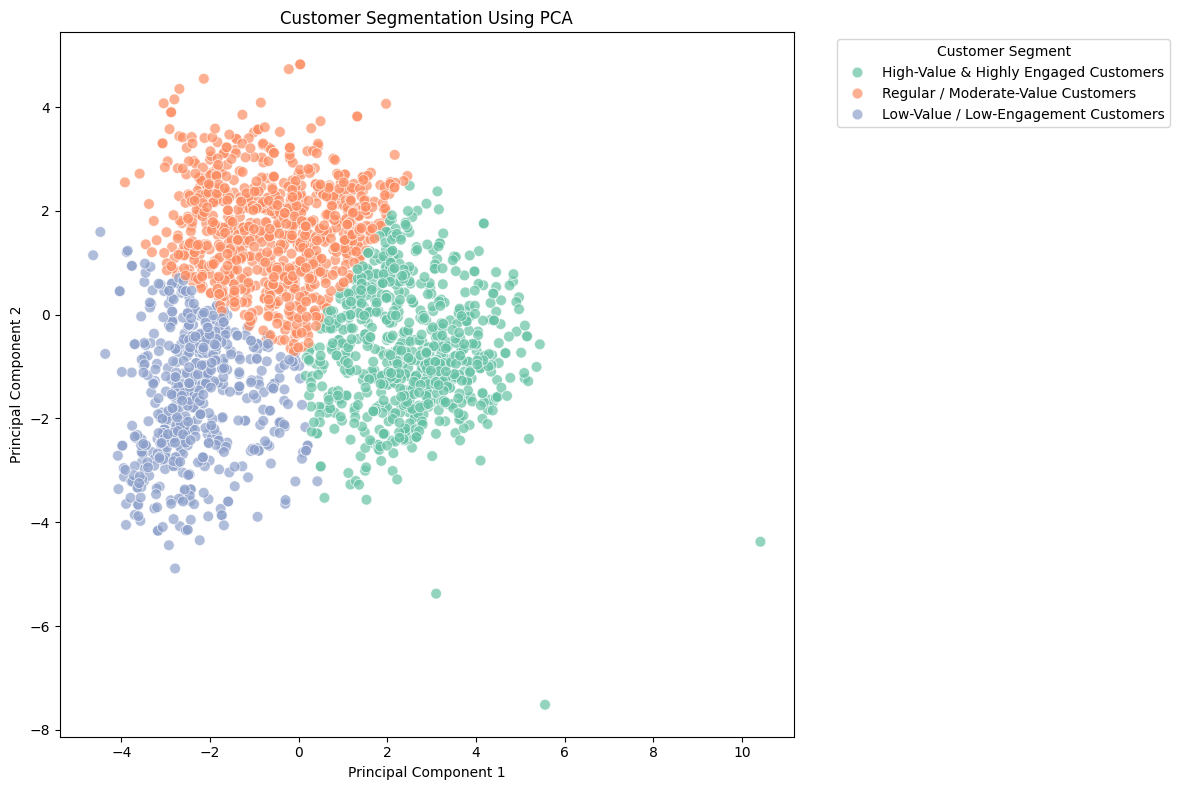

In [79]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=pca_df,
    x='PCA1',
    y='PCA2',
    hue='Customer_Segment',
    palette='Set2',
    s=60,
    alpha=0.7
)

plt.title('Customer Segmentation Using PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Customer Segment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

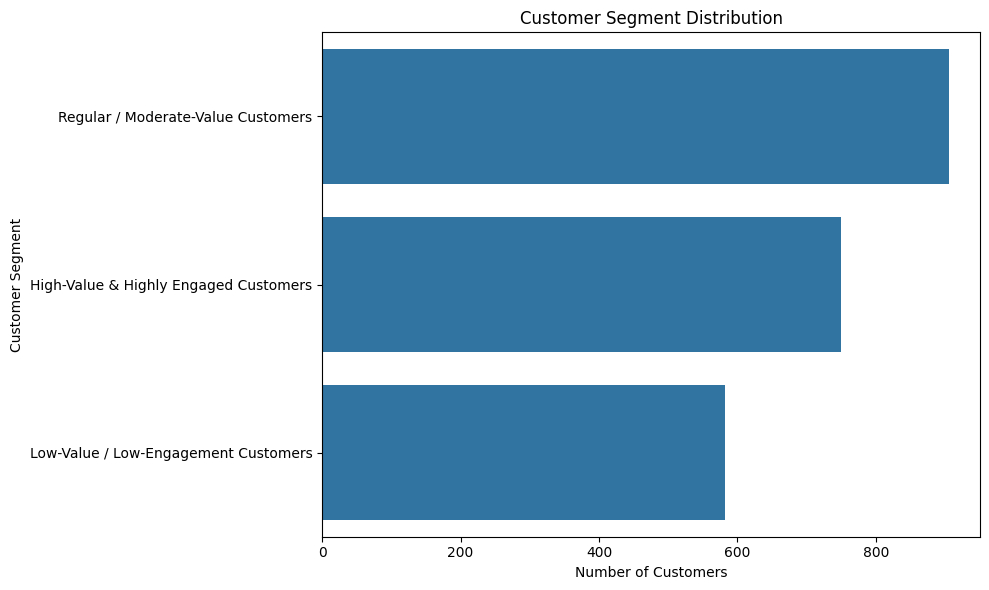

In [80]:
segment_counts = df_clean['Customer_Segment'].value_counts()

plt.figure(figsize=(10, 6))

sns.barplot(
    x=segment_counts.values,
    y=segment_counts.index
)

plt.title('Customer Segment Distribution')
plt.xlabel('Number of Customers')
plt.ylabel('Customer Segment')

plt.tight_layout()
plt.show()

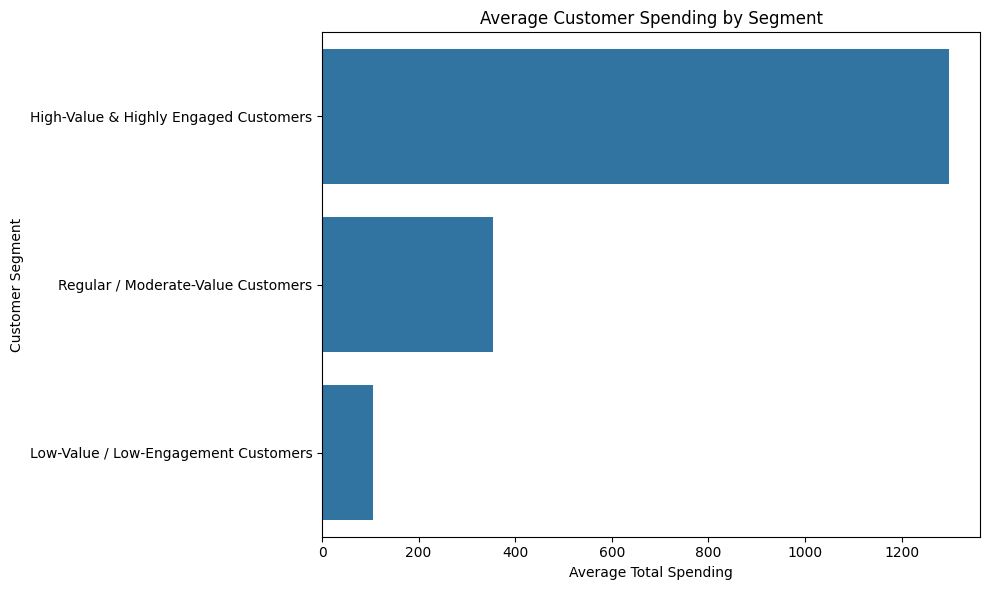

In [81]:
segment_spending = (
    df_clean.groupby('Customer_Segment')['Total_Spending']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=segment_spending.values,
    y=segment_spending.index
)

plt.title('Average Customer Spending by Segment')
plt.xlabel('Average Total Spending')
plt.ylabel('Customer Segment')

plt.tight_layout()
plt.show()

In [82]:
purchase_comparison = (
    df_clean.groupby('Customer_Segment')[
        ['Total_Purchases', 'Total_Spending', 'Recency']
    ]
    .mean()
    .round(2)
)

purchase_comparison

,Total_Purchases,Total_Spending,Recency
Customer_Segment,,,
High-Value & Highly Engaged Customers,19.80,1297.47,49.05
Low-Value / Low-Engagement Customers,5.89,105.46,49.44
Regular / Moderate-Value Customers,10.81,354.22,48.93


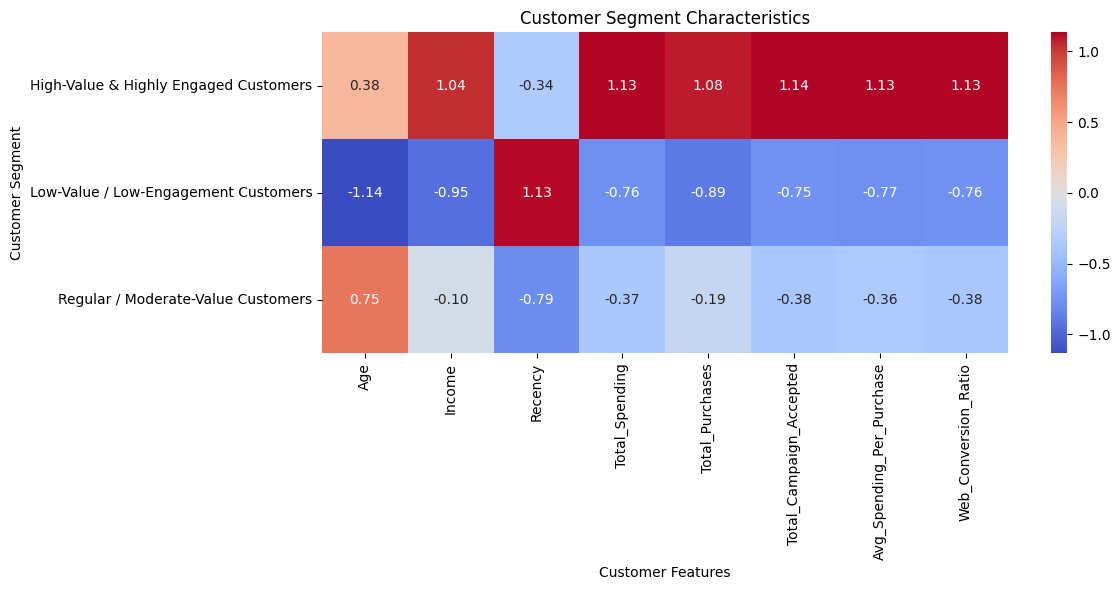

In [83]:
heatmap_features = [
    'Age',
    'Income',
    'Recency',
    'Total_Spending',
    'Total_Purchases',
    'Total_Campaign_Accepted',
    'Avg_Spending_Per_Purchase',
    'Web_Conversion_Ratio'
]

heatmap_data = (
    df_clean.groupby('Customer_Segment')[heatmap_features]
    .mean()
)

heatmap_normalized = (
    heatmap_data - heatmap_data.mean()
) / heatmap_data.std()

plt.figure(figsize=(12, 6))

sns.heatmap(
    heatmap_normalized,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f'
)

plt.title('Customer Segment Characteristics')
plt.xlabel('Customer Features')
plt.ylabel('Customer Segment')

plt.tight_layout()
plt.show()

In [84]:
preference_comparison = (
    df_clean.groupby('Customer_Segment')[spending_cols]
    .mean()
)

preference_comparison

,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
Customer_Segment,,,,,,
High-Value & Highly Engaged Customers,606.688000,60.930667,404.457333,87.330667,62.938667,75.124000
Low-Value / Low-Engagement Customers,22.902062,10.049828,26.054983,14.823024,9.809278,21.819588
Regular / Moderate-Value Customers,233.914917,7.977901,60.647514,10.844199,8.441989,32.393370


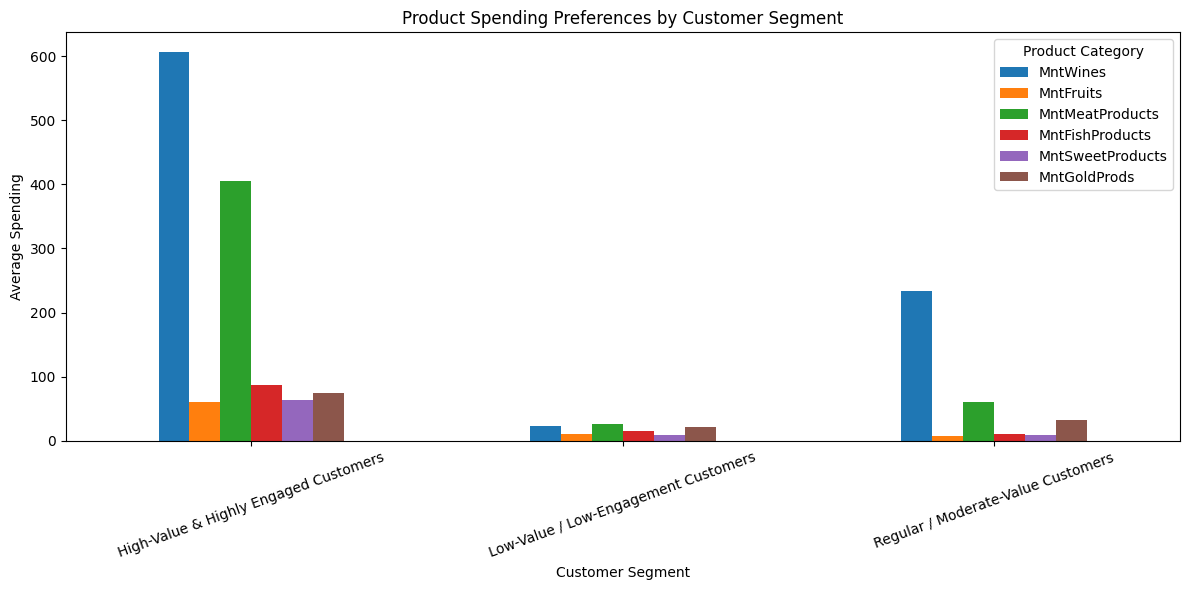

In [85]:
preference_comparison.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Product Spending Preferences by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Average Spending')
plt.xticks(rotation=20)
plt.legend(title='Product Category')
plt.tight_layout()
plt.show()

In [86]:
business_strategy = pd.DataFrame({
    'Customer Segment': [
        'High-Value & Highly Engaged Customers',
        'Regular / Moderate-Value Customers',
        'Low-Value / Low-Engagement Customers'
    ],
    'Key Characteristics': [
        'High income, high spending, frequent purchases and strong campaign engagement',
        'Moderate income, spending and purchase frequency; largest customer group',
        'Low income, low spending and low purchase frequency; weak campaign conversion'
    ],
    'Recommended Strategy': [
        'VIP loyalty programs, premium offers, early product access and personalized cross-selling',
        'Loyalty rewards, personalized discounts and cross-selling to increase purchase frequency',
        'Re-engagement campaigns, targeted discounts and website conversion-focused offers'
    ]
})

business_strategy

,Customer Segment,Key Characteristics,Recommended Strategy
0,High-Value & Highly Engaged Customers,"High income, high spending, frequent purchases...","VIP loyalty programs, premium offers, early pr..."
1,Regular / Moderate-Value Customers,"Moderate income, spending and purchase frequen...","Loyalty rewards, personalized discounts and cr..."
2,Low-Value / Low-Engagement Customers,"Low income, low spending and low purchase freq...","Re-engagement campaigns, targeted discounts an..."


In [87]:
final_customer_data = df_clean[
    [
        'ID',
        'Age',
        'Education',
        'Marital_Status',
        'Income',
        'Total_Spending',
        'Total_Purchases',
        'Recency',
        'Total_Campaign_Accepted',
        'NumWebPurchases',
        'NumCatalogPurchases',
        'NumStorePurchases',
        'Customer_Segment'
    ]
].copy()

In [88]:
final_customer_data.head(10)

,ID,Age,Education,Marital_Status,Income,Total_Spending,Total_Purchases,Recency,Total_Campaign_Accepted,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,Customer_Segment
0,5524,57,Graduation,Single,58138.0,1617,22,58,0,8,10,4,High-Value & Highly Engaged Customers
1,2174,60,Graduation,Single,46344.0,27,4,38,0,1,1,2,Regular / Moderate-Value Customers
2,4141,49,Graduation,Together,71613.0,776,20,26,0,8,2,10,High-Value & Highly Engaged Customers
3,6182,30,Graduation,Together,26646.0,53,6,26,0,2,0,4,Low-Value / Low-Engagement Customers
4,5324,33,PhD,Married,58293.0,422,14,94,0,5,3,6,Regular / Moderate-Value Customers
5,7446,47,Master,Together,62513.0,716,20,16,0,6,4,10,Regular / Moderate-Value Customers
6,965,43,Graduation,Divorced,55635.0,590,17,34,0,7,3,7,High-Value & Highly Engaged Customers
7,6177,29,PhD,Married,33454.0,169,8,32,0,4,0,4,Low-Value / Low-Engagement Customers
8,4855,40,PhD,Together,30351.0,46,5,19,0,3,0,2,Low-Value / Low-Engagement Customers
9,5899,64,PhD,Together,5648.0,49,1,68,1,1,0,0,Regular / Moderate-Value Customers


In [89]:
final_customer_data.to_csv(
    'customer_segmentation_results.csv',
    index=False
)

In [90]:
evaluation_summary = pd.DataFrame({
    'K': list(K_range),
    'Inertia': inertia,
    'Silhouette Score': silhouette_scores,
    'Davies-Bouldin Score': davies_scores,
    'Calinski-Harabasz Score': calinski_scores
})

evaluation_summary

,K,Inertia,Silhouette Score,Davies-Bouldin Score,Calinski-Harabasz Score
0,2,29793.699634,0.209908,1.749409,617.778139
1,3,25732.173346,0.189451,1.669131,533.789167
2,4,23748.315123,0.150467,1.803122,447.593428
3,5,22461.679974,0.149706,1.845720,386.728178
4,6,21502.876852,0.139582,1.922159,342.928818
5,7,20435.034133,0.129383,1.766012,319.994114
6,8,19441.838692,0.137991,1.744256,304.430220
7,9,18803.322701,0.134900,1.827977,284.755584
8,10,17539.446157,0.139331,1.677240,289.064217


# Customer Segmentation Using Machine Learning

## 1. Project Overview

This project uses machine learning to segment customers based on their demographic characteristics, purchasing behavior, product preferences, and engagement patterns.

The objective is to identify meaningful customer groups using unsupervised learning and convert the resulting segments into actionable business strategies.

### Objectives

- Analyze customer demographics and purchasing behavior.
- Identify customer preferences across product categories.
- Engineer meaningful customer-level behavioral features.
- Apply K-Means clustering using Scikit-learn.
- Determine an appropriate number of customer segments.
- Evaluate cluster quality using multiple metrics.
- Visualize customer segments using PCA.
- Profile each customer segment.
- Generate targeted marketing strategies for each segment.

## 2. Dataset Description

The project uses the Customer Personality Analysis dataset containing customer demographic, purchasing, channel, and campaign-response information.

### Dataset Size

- Original records: 2,240 customers
- Original features: 29
- Cleaned records used for modeling: 2,237

### Major Data Categories

**Demographic features**
- Age
- Education
- Marital Status
- Income
- Household composition

**Purchase behavior**
- Recency
- Product-category spending
- Web purchases
- Catalog purchases
- Store purchases
- Deal purchases

**Customer engagement**
- Website visits
- Campaign responses
- Complaint information

The dataset provides sufficient information to perform behavioral and demographic customer segmentation.

## 3. Data Preprocessing

The following preprocessing operations were performed:

1. Created a separate cleaned dataset while preserving the original data.
2. Checked for duplicate records.
3. Identified missing income values.
4. Replaced the extreme income value of 666,666 with a missing value because it was inconsistent with the overall income distribution.
5. Imputed missing income values using the median.
6. Identified three unrealistic birth-year records that resulted in ages above 100.
7. Removed these three anomalous records.
8. Removed constant features (`Z_CostContact` and `Z_Revenue`) because they provided no information for clustering.
9. Converted customer registration dates into a customer-tenure feature.
10. Grouped extremely rare marital-status categories into `Other`.

## 4. Feature Engineering

Additional customer-level features were created to better represent customer behavior.

### Behavioral Features

- Total Spending
- Total Purchases
- Total Children
- Total Campaigns Accepted
- Total Purchase Channels
- Average Spending per Purchase
- Web Conversion Ratio
- Household Size

### Preference Features

Spending-share features were created for:

- Wine
- Fruits
- Meat
- Fish
- Sweets
- Gold

These engineered features allow the clustering algorithm to consider not only how much customers spend, but also how they purchase, engage, and distribute their spending across product categories.

## 5. Machine Learning Methodology

K-Means clustering was selected as the primary unsupervised learning algorithm.

### Why K-Means?

K-Means groups customers according to similarity in their demographic and behavioral characteristics.

The algorithm assigns each customer to the nearest cluster centroid and iteratively updates the centroids until the clusters stabilize.

### Feature Scaling

StandardScaler was used before clustering because the selected features have very different numerical ranges.

Scaling prevents large-valued features such as income and total spending from dominating the distance calculations.

### Number of Clusters

Candidate values of K from 2 to 10 were evaluated using:

- Elbow Method
- Silhouette Score
- Davies-Bouldin Score
- Calinski-Harabasz Score

A final value of K = 3 was selected based on the combined evaluation results and the business interpretability of the resulting customer groups.

## 6. Final Customer Segments

The K-Means model identified three meaningful customer segments.

### Segment 1 — High-Value & Highly Engaged Customers

**750 customers — 33.5%**

Characteristics:
- Highest average income
- Highest total spending
- Highest purchase frequency
- Highest campaign engagement
- Highest average spending per purchase
- Strong online conversion
- Strong purchasing across multiple product categories

**Recommended strategy:**
- VIP loyalty programs
- Premium offers
- Early access to products
- Personalized recommendations
- Cross-selling and upselling

---

### Segment 2 — Regular / Moderate-Value Customers

**905 customers — 40.5%**

Characteristics:
- Largest customer segment
- Moderate income
- Moderate spending
- Moderate purchase frequency
- Established purchasing activity
- Strong store purchasing behavior

**Recommended strategy:**
- Loyalty rewards
- Personalized discounts
- Cross-selling
- Purchase-frequency incentives
- Strategies to move customers toward the high-value segment

---

### Segment 3 — Low-Value / Low-Engagement Customers

**582 customers — 26.0%**

Characteristics:
- Lowest average income
- Lowest spending
- Lowest purchase frequency
- Lowest campaign engagement
- Lowest web conversion
- Relatively high website visits compared with their web purchases

**Recommended strategy:**
- Re-engagement campaigns
- Targeted discounts
- Personalized product recommendations
- Website conversion offers
- Identify barriers preventing purchase

## 7. Key Business Insights

### Insight 1 — High-value customers drive substantial spending

The High-Value & Highly Engaged segment has substantially higher spending and purchase frequency than the other segments, making customer retention particularly important.

### Insight 2 — The regular segment represents the largest opportunity

Regular / Moderate-Value Customers form the largest group. Increasing their purchase frequency and average spending could provide significant business value.

### Insight 3 — Low-value customers present a conversion opportunity

The Low-Value / Low-Engagement segment has relatively high website visits but low web conversion. This suggests an opportunity for targeted online promotions and improved personalization.

### Insight 4 — Product preferences differ between segments

The high-value segment spends substantially more across all major product categories, while the regular segment shows a particularly strong preference for wine.

### Insight 5 — Customer segmentation enables targeted marketing

Different segments exhibit clearly different spending, engagement, and purchasing characteristics. Therefore, applying the same marketing strategy to every customer would be less effective than segment-specific campaigns.

## 8. Conclusion

This project successfully applied machine learning to customer segmentation using demographic and behavioral information.

Through data preprocessing, feature engineering, exploratory analysis, K-Means clustering, cluster validation, and PCA visualization, three meaningful customer segments were identified:

1. High-Value & Highly Engaged Customers
2. Regular / Moderate-Value Customers
3. Low-Value / Low-Engagement Customers

The resulting segmentation provides actionable insights that can support personalized marketing, customer retention, cross-selling, re-engagement, and conversion strategies.

The project demonstrates the practical use of Python and Scikit-learn for customer analytics and unsupervised machine learning.

In [91]:
from google.colab import files

files.download('customer_segmentation_results.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [92]:
final_customer_data.shape

(2237, 13)

In [94]:
final_customer_data['Customer_Segment'].value_counts()

,count
Customer_Segment,
Regular / Moderate-Value Customers,905
High-Value & Highly Engaged Customers,750
Low-Value / Low-Engagement Customers,582


# Customer Segmentation Using Machine Learning

## Project Overview

This project applies unsupervised machine learning to segment customers based on demographic characteristics, purchasing behavior, product preferences, and customer engagement.

The objective is to identify meaningful customer groups and generate targeted business strategies for each segment.

## Dataset

The project uses the Customer Personality Analysis dataset.

Original dataset:
- 2,240 customers
- 29 features

After data preprocessing:
- 2,237 customers
- 17 features used for clustering

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Google Colab

## Machine Learning Methodology

The project follows these steps:

1. Data loading
2. Data quality assessment
3. Data cleaning
4. Exploratory Data Analysis
5. Feature engineering
6. Feature scaling
7. K-Means clustering
8. Optimal cluster selection
9. Cluster validation
10. PCA visualization
11. Customer segment profiling
12. Business insight generation

## Feature Engineering

The following customer-level features were created:

- Total Spending
- Total Purchases
- Total Children
- Total Campaigns Accepted
- Total Purchase Channels
- Average Spending per Purchase
- Web Conversion Ratio
- Household Size
- Product Spending Shares
- Customer Tenure

## Cluster Selection

Multiple methods were used to determine an appropriate number of clusters:

- Elbow Method
- Silhouette Score
- Davies-Bouldin Score
- Calinski-Harabasz Score

Based on the combined evaluation and business interpretability, K = 3 was selected.

## Final Customer Segments

### 1. High-Value & Highly Engaged Customers

- 750 customers
- Highest income
- Highest spending
- Highest purchase frequency
- Strong campaign engagement
- Strong online conversion

Recommended strategies:
- VIP loyalty programs
- Premium offers
- Personalized recommendations
- Cross-selling and upselling

### 2. Regular / Moderate-Value Customers

- 905 customers
- Largest customer segment
- Moderate income
- Moderate spending
- Moderate purchase frequency

Recommended strategies:
- Loyalty rewards
- Personalized discounts
- Cross-selling
- Purchase-frequency incentives

### 3. Low-Value / Low-Engagement Customers

- 582 customers
- Lowest income
- Lowest spending
- Lowest purchase frequency
- Low campaign engagement
- Low web conversion despite relatively high website visits

Recommended strategies:
- Re-engagement campaigns
- Targeted discounts
- Personalized recommendations
- Website conversion-focused offers

## Key Business Insights

- High-value customers contribute substantially more spending and purchasing activity.
- Regular customers represent the largest segment and provide an opportunity for value growth.
- Low-value customers show a conversion opportunity because website visits are relatively high compared with web purchases.
- Product preferences vary significantly between customer segments.
- Segment-specific marketing strategies can be more effective than treating all customers identically.

## Results

The final model assigns every customer to one of three machine-learning-generated segments.

The final output is saved as:

`customer_segmentation_results.csv`

## Future Improvements

Potential future improvements include:

- Comparing K-Means with DBSCAN and hierarchical clustering
- Using automated hyperparameter optimization
- Building a customer lifetime value model
- Developing a recommendation system
- Deploying the segmentation model as a web application
- Creating an interactive Streamlit dashboard
- Adding real-time customer scoring